In [20]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [22]:
import pandas as pd
import numpy as np
import joblib

In [23]:
import sklearn
print(sklearn.__version__) 

1.7.2


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [25]:
df = pd.read_csv("C:\\Users\\NEETHU ANTONY A\\OneDrive\\Desktop\\Projects\\house_price_prediction\\ml_model\\dataset\\houses.csv")

In [26]:
df.head

<bound method NDFrame.head of      bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0         3.0       1.00       1180.0    5650.0     1.0         0.0   0.0   
1         3.0       2.25       2570.0    7242.0     2.0         0.0   0.0   
2         2.0       1.00        770.0   10000.0     1.0         0.0   0.0   
3         4.0       3.00       1960.0    5000.0     1.0         0.0   0.0   
4         3.0       2.00       1680.0    8080.0     1.0         0.0   0.0   
..        ...        ...          ...       ...     ...         ...   ...   
995       4.0       2.50       1860.0    6325.0     2.0         0.0   0.0   
996       2.0       2.75       1590.0   20917.0     1.5         0.0   0.0   
997       2.0       1.00        850.0    2340.0     1.0         0.0   0.0   
998       2.0       1.00       1030.0    4188.0     1.0         0.0   0.0   
999       NaN        NaN          NaN       NaN     NaN         NaN   NaN   

     condition  grade  sqft_above  sqft_basem

In [27]:
df.isnull().sum()

bedrooms         1
bathrooms        1
sqft_living      1
sqft_lot         1
floors           1
waterfront       1
view             1
condition        1
grade            1
sqft_above       1
sqft_basement    1
yr_built         1
yr_renovated     1
zipcode          1
lat              1
long             1
sqft_living15    1
price            1
dtype: int64

In [28]:
df=df.dropna()

In [29]:
df

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,price
0,3.0,1.00,1180.0,5650.0,1.0,0.0,0.0,3.0,7.0,1180.0,0.0,1955.0,0.0,98178.0,47.5112,-122.257,1340.0,22.190
1,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3.0,7.0,2170.0,400.0,1951.0,1991.0,98125.0,47.7210,-122.319,1690.0,53.800
2,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3.0,6.0,770.0,0.0,1933.0,0.0,98028.0,47.7379,-122.233,2720.0,18.000
3,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5.0,7.0,1050.0,910.0,1965.0,0.0,98136.0,47.5208,-122.393,1360.0,60.400
4,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3.0,8.0,1680.0,0.0,1987.0,0.0,98074.0,47.6168,-122.045,1800.0,51.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,2.0,1.00,740.0,6460.0,1.0,0.0,0.0,3.0,6.0,740.0,0.0,1953.0,0.0,98146.0,47.5077,-122.344,1170.0,17.850
995,4.0,2.50,1860.0,6325.0,2.0,0.0,0.0,4.0,7.0,1860.0,0.0,1991.0,0.0,98038.0,47.3492,-122.030,1860.0,29.100
996,2.0,2.75,1590.0,20917.0,1.5,0.0,0.0,3.0,5.0,1590.0,0.0,1920.0,0.0,98001.0,47.2786,-122.250,1310.0,19.995
997,2.0,1.00,850.0,2340.0,1.0,0.0,0.0,3.0,7.0,850.0,0.0,1922.0,0.0,98105.0,47.6707,-122.328,1300.0,55.350


In [30]:
df.isnull().sum()

bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
price            0
dtype: int64

In [31]:
X = df.drop("price", axis=1)
y = df["price"]


In [32]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)])

In [34]:
experiments = {
    "exp_1":{
        "hidden_layer_sizes": (64, 32),
        "activation": "identity",
        "learning_rate": "adaptive",
        "max_iter": 2000,
        "validation_fraction": 0.1,
        "early_stopping": True,
        "random_state": 42
    },
    "exp_2":{
        "hidden_layer_sizes": (64, 32),
        "activation": "identity",
        "learning_rate": "adaptive",
        "max_iter": 2000,
        "validation_fraction": 0.2,
        "early_stopping": True,
        "random_state": 42
    },
    "exp_3":{
        "hidden_layer_sizes": (64, 32),
        "activation": "relu",
        "learning_rate": "adaptive",
        "max_iter": 2000,
        "validation_fraction": 0.1,
        "early_stopping": True,
        "random_state": 42
    },
    "exp_4":{
        "hidden_layer_sizes": (64, 32),
        "activation": "relu",
        "learning_rate": "adaptive",
        "max_iter": 2000,
        "validation_fraction": 0.2,
        "early_stopping": True,
        "random_state": 42
    },
        "exp_5":{
            "hidden_layer_sizes": (64,32),
            "activation": "tanh",
            "learning_rate": "adaptive",
            "max_iter": 2000,
            "validation_fraction": 0.1,
            "early_stopping": True,
            "random_state": 42
    },
        "exp_6":{
            "hidden_layer_sizes": (64, 32),
            "activation": "tanh",
            "learning_rate": "adaptive",
            "max_iter": 2000,
            "validation_fraction": 0.2,
            "early_stopping": True,
            "random_state": 42
    },
        "exp_7":{
            "hidden_layer_sizes": (64,32),
            "activation": "logistic",
            "learning_rate": "adaptive",
            "max_iter": 2000,
            "validation_fraction": 0.1,
            "early_stopping": True,
            "random_state": 42
    },
        "exp_8":{
            "hidden_layer_sizes": (64,32),
            "activation": "logistic",
            "learning_rate": "adaptive",
            "max_iter": 2000,
            "validation_fraction": 0.2,
            "early_stopping": True,
            "random_state": 42
    },
}


In [35]:
for exp_name, exp_params in experiments.items():
    # Create the model with the specified parameters
    model = MLPRegressor(
        **exp_params
    )

    # Create a pipeline that combines the preprocessor and the model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Train the model
    pipeline.fit(X_train, y_train)

    # Save the model
    joblib.dump(pipeline, f"models/{exp_name}_model.pkl")

c:\Users\NEETHU ANTONY A\OneDrive\Desktop\Projects\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [36]:
experiment_results = {}
import os
files = os.listdir("models")
for file in files:
    if file.endswith(".pkl"):
        exp_name = file.replace("_model.pkl", "")

    # Load model
    pipeline = joblib.load(f"models/{file}")

    # Predict
    y_pred = pipeline.predict(X_test)

    # Store results
    experiment_results[exp_name] = {}
    experiment_results[exp_name]["R2 Score"] = r2_score(y_test, y_pred)
    experiment_results[exp_name]["MAE"] = mean_absolute_error(y_test, y_pred)
    experiment_results[exp_name]["MSE"] = mean_squared_error(y_test, y_pred)
    experiment_results[exp_name]["RMSE"] = np.sqrt(
        experiment_results[exp_name]["MSE"]
    )

#save experiment results as csv file
results_df = pd.DataFrame(experiment_results).T
results_df.to_csv("experiment_results.csv", index=True)


# Print All Results
for exp_name, metrics in experiment_results.items():
    print(f"\nModel Performance of {exp_name}:")
    for metric, value in metrics.items():
        print(f"{metric}: {value}")



Model Performance of exp_1:
R2 Score: 0.6715239962712558
MAE: 10.813197983592907
MSE: 295.3121499595565
RMSE: 17.184648671403107

Model Performance of exp_2:
R2 Score: 0.6655991420785698
MAE: 10.965483626766694
MSE: 300.6388143428819
RMSE: 17.338939250798532

Model Performance of exp_3:
R2 Score: 0.7023837348248763
MAE: 10.591993609514935
MSE: 267.5680967075412
RMSE: 16.357508878418535

Model Performance of exp_4:
R2 Score: 0.6928677016709828
MAE: 10.974892042294295
MSE: 276.1233646049288
RMSE: 16.61696014934527

Model Performance of exp_5:
R2 Score: 0.7133816477811978
MAE: 8.877960011174304
MSE: 257.6805637269541
RMSE: 16.05243170759353

Model Performance of exp_6:
R2 Score: 0.618742083278536
MAE: 8.096821169049518
MSE: 342.7650537574553
RMSE: 18.513915138550658

Model Performance of exp_7:
R2 Score: 0.7491728648304294
MAE: 8.028953181388625
MSE: 225.5029278068396
RMSE: 15.016754902669206

Model Performance of exp_8:
R2 Score: 0.7030039315447232
MAE: 7.933000653282785
MSE: 267.010516

In [37]:
#calculate the total mean squared error 
total_mse = 0
for file in files:
    if file.endswith(".pkl"):
        pipeline = joblib.load(f"models/{file}")
        y_pred = pipeline.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        total_mse += mse
        print(f"Mean Squared Error for {file}: {mse}")

print(f"Total Mean Squared Error: {total_mse}")

Mean Squared Error for exp_1_model.pkl: 295.3121499595565
Mean Squared Error for exp_2_model.pkl: 300.6388143428819
Mean Squared Error for exp_3_model.pkl: 267.5680967075412
Mean Squared Error for exp_4_model.pkl: 276.1233646049288
Mean Squared Error for exp_5_model.pkl: 257.6805637269541
Mean Squared Error for exp_6_model.pkl: 342.7650537574553
Mean Squared Error for exp_7_model.pkl: 225.5029278068396
Mean Squared Error for exp_8_model.pkl: 267.0105167788499
Total Mean Squared Error: 2232.601487685007


In [38]:
!pip install matplotlib

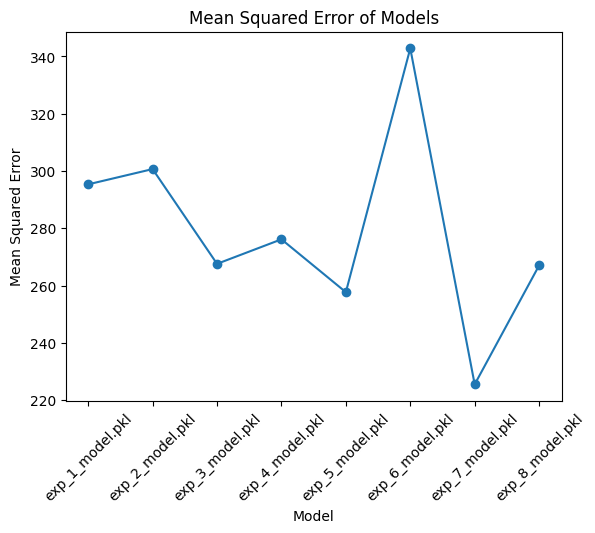

In [39]:
import matplotlib.pyplot as plt

#draw a line graph using total mean squared error
plt.plot(files, [mean_squared_error(y_test, joblib.load(f"models/{file}").predict(X_test)) for file in files], marker='o')
plt.title("Mean Squared Error of Models")
plt.xlabel("Model")
plt.ylabel("Mean Squared Error")
plt.xticks(rotation=45)
plt.show() 
